In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import mlflow
import mlflow.lightgbm

In [2]:
veri = pd.read_pickle('../data/processed/06_model-3.pkl')

In [3]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16861 entries, 2024-01-18 23:00:00 to 2025-12-20 11:00:00
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   PTF               16861 non-null  float64 
 1   month             16861 non-null  category
 2   day               16861 non-null  category
 3   season            16861 non-null  category
 4   Rolling_Mean_168  16861 non-null  float64 
 5   Is_Holiday        16861 non-null  category
 6   Is_Weekend        16861 non-null  category
 7   Lag_24            16861 non-null  float64 
 8   Lag_168           16861 non-null  float64 
 9   Lag_48            16861 non-null  float64 
 10  Lag_72            16861 non-null  float64 
 11  Lag_96            16861 non-null  float64 
 12  Hour              16861 non-null  int32   
 13  DayOfWeek         16861 non-null  int32   
 14  Yuk_Tahmin_Plani  16861 non-null  int64   
 15  yesil_enerji      16861 non-null  f

In [4]:
veri['Is_Weekend'] = (veri['DayOfWeek'] >= 5).astype(int)
# 0: Hafta İçi
# 1: Cumartesi (Yarı yoğun)
# 2: Pazar (Ölü gün)
def gun_tipi_belirle(row):
    if row['DayOfWeek'] == 6: # Pazar
        return 2
    elif row['DayOfWeek'] == 5: # Cumartesi
        return 1
    else: # Hafta İçi
        return 0

veri['Gun_Tipi'] = veri.apply(gun_tipi_belirle, axis=1)


# Kontrol edelim
print(veri[['DayOfWeek', 'Is_Weekend', 'Gun_Tipi']].head(10)) # İlk günler
print(veri[['DayOfWeek', 'Is_Weekend', 'Gun_Tipi']].tail(10)) # Son günler (Haftasonuna denk geliyorsa)

                     DayOfWeek  Is_Weekend  Gun_Tipi
2024-01-18 23:00:00          3           0         0
2024-01-19 00:00:00          4           0         0
2024-01-19 01:00:00          4           0         0
2024-01-19 02:00:00          4           0         0
2024-01-19 03:00:00          4           0         0
2024-01-19 04:00:00          4           0         0
2024-01-19 05:00:00          4           0         0
2024-01-19 06:00:00          4           0         0
2024-01-19 07:00:00          4           0         0
2024-01-19 08:00:00          4           0         0
                     DayOfWeek  Is_Weekend  Gun_Tipi
2025-12-20 02:00:00          5           1         1
2025-12-20 03:00:00          5           1         1
2025-12-20 04:00:00          5           1         1
2025-12-20 05:00:00          5           1         1
2025-12-20 06:00:00          5           1         1
2025-12-20 07:00:00          5           1         1
2025-12-20 08:00:00          5           1    

In [5]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16861 entries, 2024-01-18 23:00:00 to 2025-12-20 11:00:00
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   PTF               16861 non-null  float64 
 1   month             16861 non-null  category
 2   day               16861 non-null  category
 3   season            16861 non-null  category
 4   Rolling_Mean_168  16861 non-null  float64 
 5   Is_Holiday        16861 non-null  category
 6   Is_Weekend        16861 non-null  int64   
 7   Lag_24            16861 non-null  float64 
 8   Lag_168           16861 non-null  float64 
 9   Lag_48            16861 non-null  float64 
 10  Lag_72            16861 non-null  float64 
 11  Lag_96            16861 non-null  float64 
 12  Hour              16861 non-null  int32   
 13  DayOfWeek         16861 non-null  int32   
 14  Yuk_Tahmin_Plani  16861 non-null  int64   
 15  yesil_enerji      16861 non-null  f

In [7]:
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import warnings

# Gereksiz uyarıları kapatalım
warnings.filterwarnings('ignore')

print("🚀 SIFIRDAN OPTİMİZASYON BAŞLIYOR (Yeni Özellik Seti ile)...")

# 1. YENİ ÖZELLİK LİSTESİ (Hafta Sonu Dahil)
features_opt_v2 = [
    'Hour', 'DayOfWeek', 
    'Is_Weekend', 'Gun_Tipi', # Yeni eklediklerimiz
    'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       
    'Lag_24', 'Lag_168',
    'Maliyet_Baskisi'
]

# 2. VERİYİ HAZIRLA (Zaman Bazlı Ayrım)
split_date = '2025-10-01'
# NaN temizliği
model_df = veri.copy().dropna()

X_train_opt = model_df[model_df.index < split_date][features_opt_v2]
y_train_opt = model_df[model_df.index < split_date]['PTF']
X_test_opt = model_df[model_df.index >= split_date][features_opt_v2]
y_test_opt = model_df[model_df.index >= split_date]['PTF']

# 3. OBJECTIVE FONKSİYONU
def objective(trial):
    # Parametre Uzayı (Arama Aralığı)
    param = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': 5000, # Erken durdurma kullanacağız
        
        # Optimize Edilecekler:
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03), # Hassas aralık
        'num_leaves': trial.suggest_int('num_leaves', 30, 80),              # Ağaç karmaşıklığı
        'max_depth': trial.suggest_int('max_depth', 8, 15),                 # Derinlik sınırı
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),           # Satır örnekleme
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95), # Sütun örnekleme
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),            # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 0.5),          # L2
    }

    model = lgb.LGBMRegressor(**param)
    
    model.fit(
        X_train_opt, y_train_opt,
        eval_set=[(X_test_opt, y_test_opt)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    preds = model.predict(X_test_opt)
    mae = mean_absolute_error(y_test_opt, preds)
    return mae

# 4. ÇALIŞMAYI BAŞLAT
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) # 20 Deneme yeterli olacaktır

print("\n" + "="*40)
print("🏆 YENİ EN İYİ PARAMETRELER:")
print("="*40)
print(f"🥇 En Düşük MAE: {study.best_value:.2f} TL")
print("🧩 Parametreler:", study.best_params)

c:\Users\90546\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-25 17:44:28,557] A new study created in memory with name: no-name-a8f0c014-481b-48dc-aaf1-ebaa56b0bca1


🚀 SIFIRDAN OPTİMİZASYON BAŞLIYOR (Yeni Özellik Seti ile)...


[I 2025-12-25 17:44:32,197] Trial 0 finished with value: 232.33356949219248 and parameters: {'learning_rate': 0.005078021671934872, 'num_leaves': 64, 'max_depth': 15, 'min_child_samples': 35, 'subsample': 0.7915580045369244, 'colsample_bytree': 0.703845445036141, 'reg_alpha': 0.26010874187521393, 'reg_lambda': 0.08858209568364273}. Best is trial 0 with value: 232.33356949219248.
[I 2025-12-25 17:44:33,516] Trial 1 finished with value: 227.77575159424913 and parameters: {'learning_rate': 0.011479537201162297, 'num_leaves': 55, 'max_depth': 12, 'min_child_samples': 15, 'subsample': 0.7832535893799238, 'colsample_bytree': 0.7516194532608704, 'reg_alpha': 0.20136661091847713, 'reg_lambda': 0.4099878782470393}. Best is trial 1 with value: 227.77575159424913.
[I 2025-12-25 17:44:34,193] Trial 2 finished with value: 231.1141758411074 and parameters: {'learning_rate': 0.028770843970775554, 'num_leaves': 61, 'max_depth': 8, 'min_child_samples': 19, 'subsample': 0.8506909862550474, 'colsample_by


🏆 YENİ EN İYİ PARAMETRELER:
🥇 En Düşük MAE: 225.54 TL
🧩 Parametreler: {'learning_rate': 0.0090952501725702, 'num_leaves': 44, 'max_depth': 11, 'min_child_samples': 45, 'subsample': 0.631916786441584, 'colsample_bytree': 0.9366763283987434, 'reg_alpha': 0.3123680896390211, 'reg_lambda': 0.11870763850020283}


haftasonu bilgisi taşıyan model sonucları

 R2 Skoru : 0.8142
 MAE      : 225.54 TL
 WMAPE    : %8.03
 Bias     : 60.35 TL


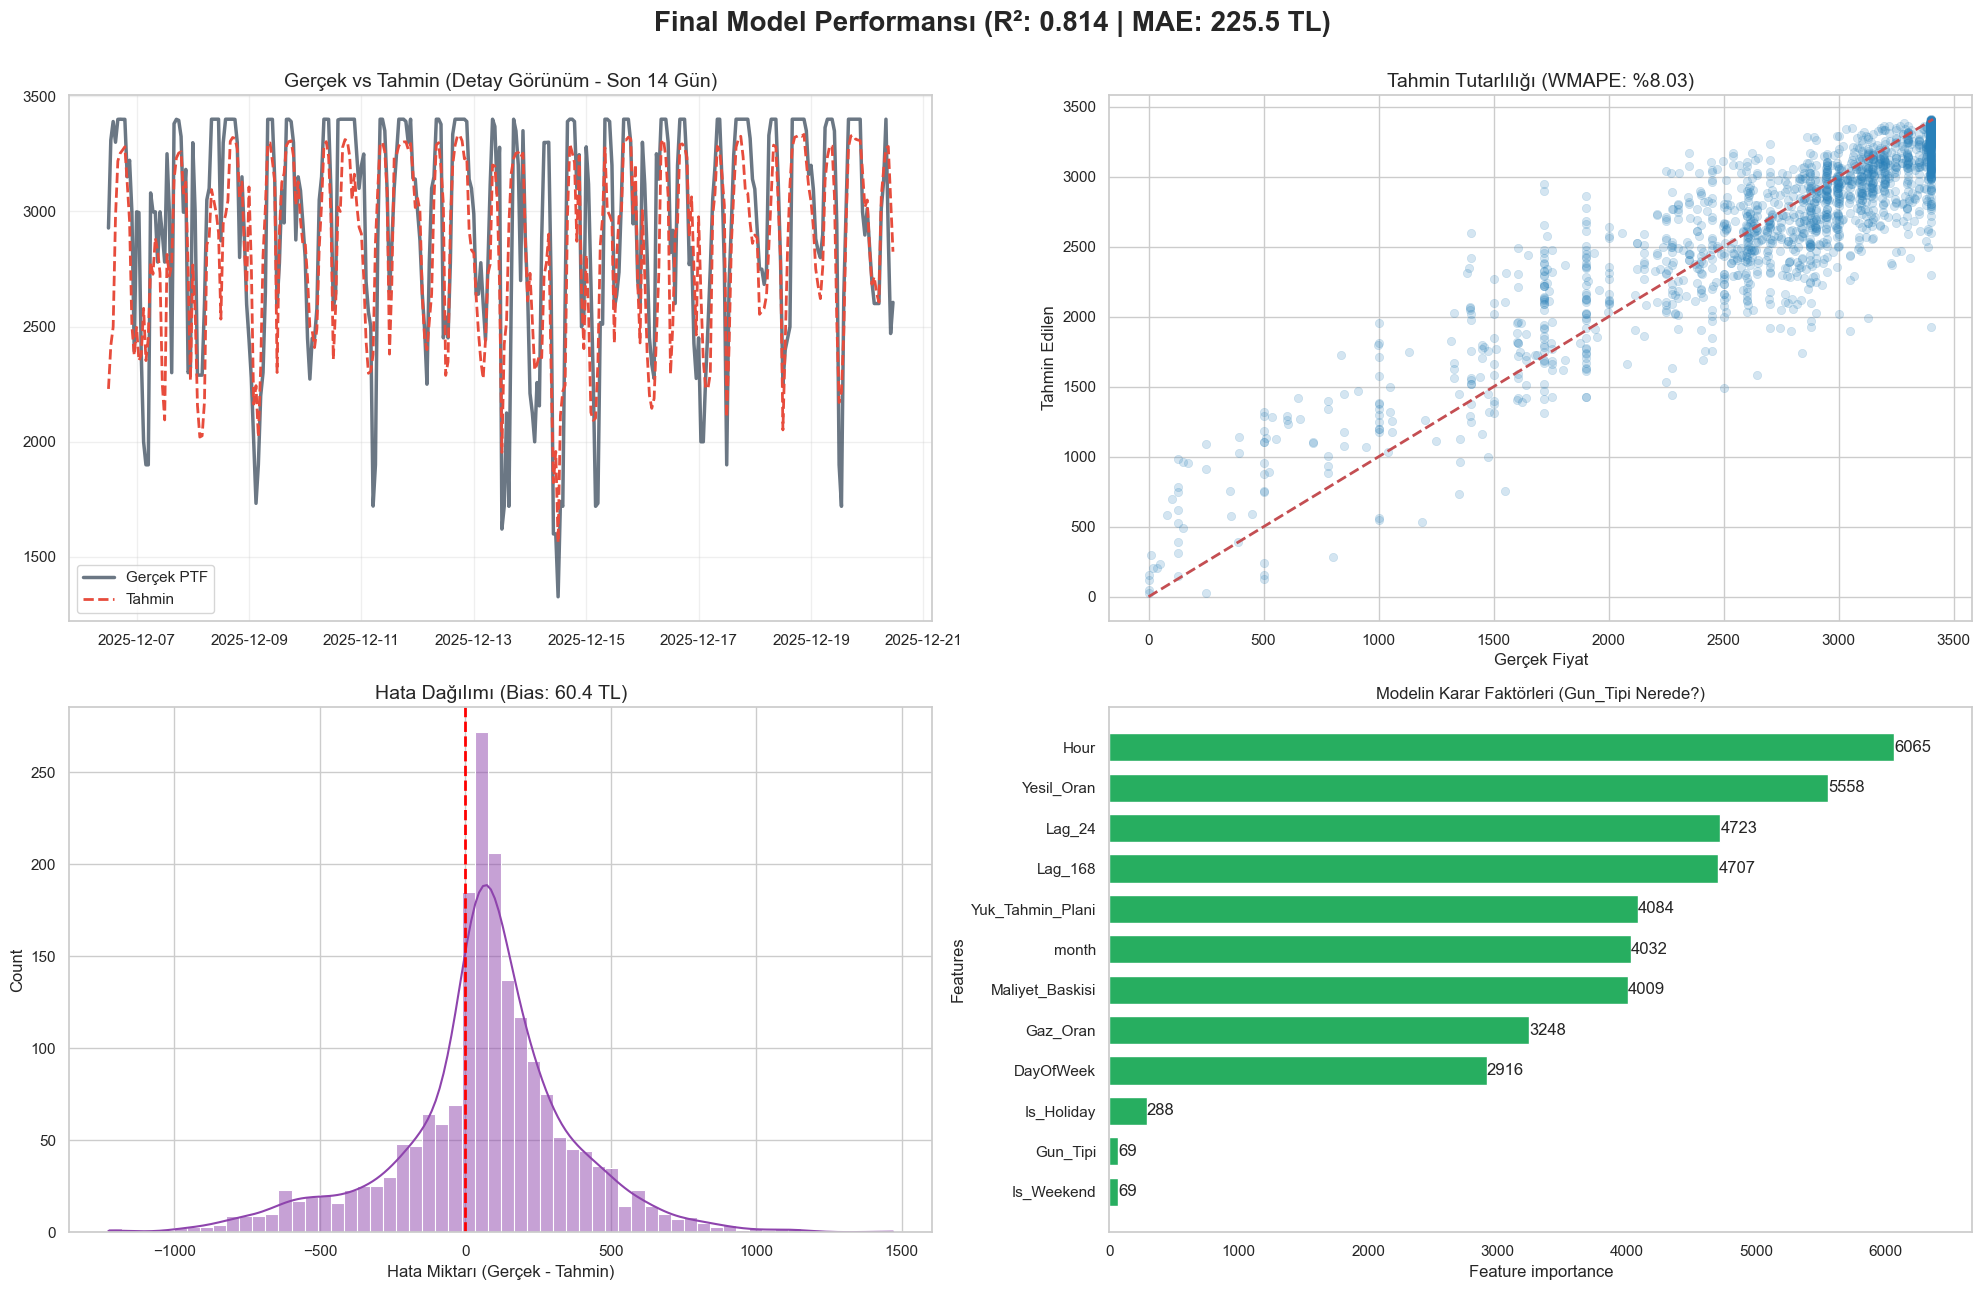

In [12]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Görsellik ayarları
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (20, 14)

print("haftasonu bilgisi taşıyan model sonucları")
# 1. EN İYİ PARAMETRELERİ AL
# Eğer 'study' nesnesi hafızadaysa ondan çek, yoksa manuel bir set kullan (Hata almamak için)
if 'study' in locals():
    best_params = study.best_params
else:
    print("⚠️ Optuna sonucu bulunamadı! Varsayılan 'Güvenli' ayarlar kullanılıyor.")
    # Manuel Güvenli Ayarlar
    best_params = {
        'learning_rate': 0.015, 'num_leaves': 55, 'max_depth': 12, 
        'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
        'reg_alpha': 0.1, 'reg_lambda': 0.1
    }

# Sabit parametreleri ekle
best_params.update({
    'objective': 'regression',
    'metric': 'mae',
    'n_estimators': 6000,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
})

# 2. MODELİ EĞİT
final_model_v2 = lgb.LGBMRegressor(**best_params)

final_model_v2.fit(
    X_train_opt, y_train_opt,
    eval_set=[(X_test_opt, y_test_opt)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# 3. TAHMİNLERİ YAP
preds_final_v2 = final_model_v2.predict(X_test_opt)

# 4. METRİKLERİ HESAPLA
r2 = r2_score(y_test_opt, preds_final_v2)
mae = mean_absolute_error(y_test_opt, preds_final_v2)
wmape = (np.sum(np.abs(y_test_opt - preds_final_v2)) / np.sum(y_test_opt)) * 100
bias = np.mean(y_test_opt - preds_final_v2)

print("\n" + "="*40)
print(f" R2 Skoru : {r2:.4f}")
print(f" MAE      : {mae:.2f} TL")
print(f" WMAPE    : %{wmape:.2f}")
print(f" Bias     : {bias:.2f} TL")
print("="*40)

# 5. PROFESYONEL GRAFİKLERİ ÇİZ
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle(f"Final Model Performansı (R²: {r2:.3f} | MAE: {mae:.1f} TL)", fontsize=20, weight='bold', y=0.95)

# Grafik A (Sol Üst): Zaman Serisi (Zoom - Son 2 Hafta)
results_df = pd.DataFrame({'Gerçek': y_test_opt, 'Tahmin': preds_final_v2}, index=X_test_opt.index)
zoom_data = results_df.tail(24 * 14) 
axes[0, 0].plot(zoom_data.index, zoom_data['Gerçek'], label='Gerçek PTF', color='#2c3e50', linewidth=2.5, alpha=0.7)
axes[0, 0].plot(zoom_data.index, zoom_data['Tahmin'], label='Tahmin', color='#e74c3c', linestyle='--', linewidth=2)
axes[0, 0].set_title('Gerçek vs Tahmin (Detay Görünüm - Son 14 Gün)', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Grafik B (Sağ Üst): Doğruluk (Scatter)
sns.scatterplot(x=y_test_opt, y=preds_final_v2, alpha=0.2, color='#2980b9', edgecolor=None, ax=axes[0, 1])
limit = max(y_test_opt.max(), preds_final_v2.max())
axes[0, 1].plot([0, limit], [0, limit], 'r--', linewidth=2, label='Mükemmel Uyum')
axes[0, 1].set_title(f'Tahmin Tutarlılığı (WMAPE: %{wmape:.2f})', fontsize=14)
axes[0, 1].set_xlabel('Gerçek Fiyat')
axes[0, 1].set_ylabel('Tahmin Edilen')

# Grafik C (Sol Alt): Hata Dağılımı (Residuals)
residuals = y_test_opt - preds_final_v2
sns.histplot(residuals, bins=60, kde=True, color='#8e44ad', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title(f'Hata Dağılımı (Bias: {bias:.1f} TL)', fontsize=14)
axes[1, 0].set_xlabel('Hata Miktarı (Gerçek - Tahmin)')

# Grafik D (Sağ Alt): Feature Importance
lgb.plot_importance(final_model_v2, max_num_features=15, height=0.7, ax=axes[1, 1], 
                    title='Modelin Karar Faktörleri (Gun_Tipi Nerede?)', color='#27ae60', importance_type='split')
axes[1, 1].grid(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Yeni 'Dip Fiyat' Avcıları Eklendi: 'Net_Yuk_Indeksi' ve 'Bolluk_Skoru'


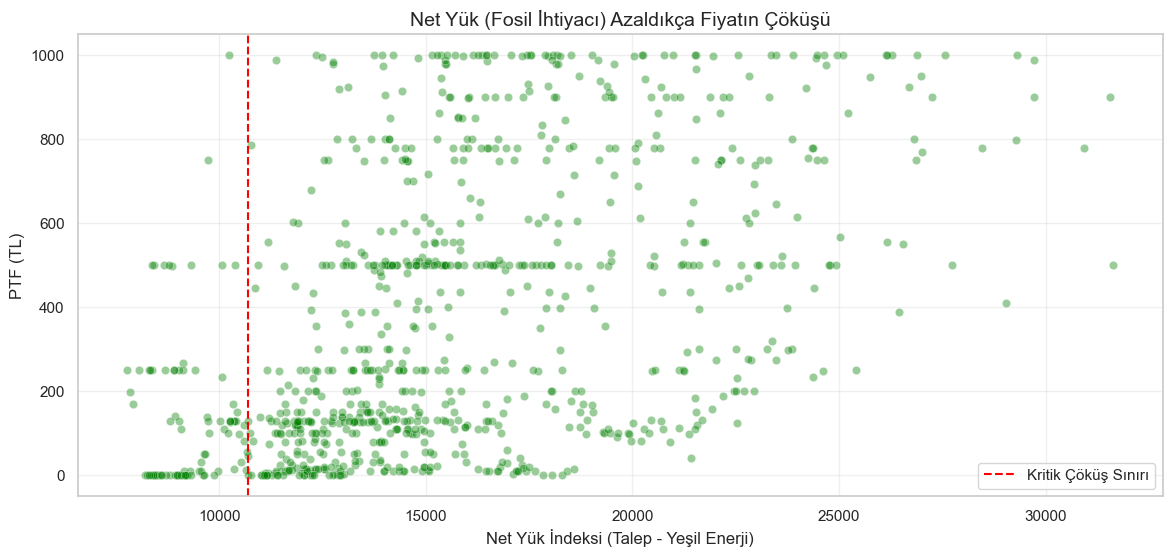

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. NET YÜK HESABI (Sanal Olarak)
# Mantık: Yeşil enerji (Rüzgar/Güneş/Su) talebin ne kadarını karşılıyor?
# Eğer Yesil_Oran %60 ise, Net Yük %40 kalmış demektir.
veri['Net_Yuk_Indeksi'] = veri['Yuk_Tahmin_Plani'] * (1 - veri['Yesil_Oran'])

# 2. BOLLUK GÖSTERGESİ (Surplus Indicator)
# Özellikle gece saatlerinde rüzgarın payı çok artarsa fiyat 0'a gider.
# Talep düşükken (Gece) ve Yeşil oran yüksekken bu sayı çok büyüyecek.
# (Yeşil Oran / Yük) bize "Birim yük başına düşen yeşil enerji"yi verir.
veri['Bolluk_Skoru'] = veri['Yesil_Oran'] / veri['Yuk_Tahmin_Plani']

print("Yeni 'Dip Fiyat' Avcıları Eklendi: 'Net_Yuk_Indeksi' ve 'Bolluk_Skoru'")

# --- GÖRSEL KANIT: DİP FİYATLARLA İLİŞKİSİ ---
# Bakalım Net Yük düştükçe fiyat gerçekten sıfıra yaklaşıyor mu?

plt.figure(figsize=(14, 6))

# Sadece Düşük Fiyatlara Odaklanalım (< 1000 TL)
low_price_data = veri[veri['PTF'] < 1000]

sns.scatterplot(x='Net_Yuk_Indeksi', y='PTF', data=low_price_data, alpha=0.4, color='green')
plt.title('Net Yük (Fosil İhtiyacı) Azaldıkça Fiyatın Çöküşü', fontsize=14)
plt.xlabel('Net Yük İndeksi (Talep - Yeşil Enerji)', fontsize=12)
plt.ylabel('PTF (TL)', fontsize=12)
plt.grid(True, alpha=0.3)

# Kritik Eşik Çizgisi (Tahmini)
plt.axvline(x=low_price_data['Net_Yuk_Indeksi'].quantile(0.1), color='red', linestyle='--', label='Kritik Çöküş Sınırı')
plt.legend()
plt.show()

KORELASYON ANALİZİ SONUÇLARI:
----------------------------------------
Net Yük İndeksi vs PTF : 0.6250
Bolluk Skoru vs PTF    : -0.6603
----------------------------------------


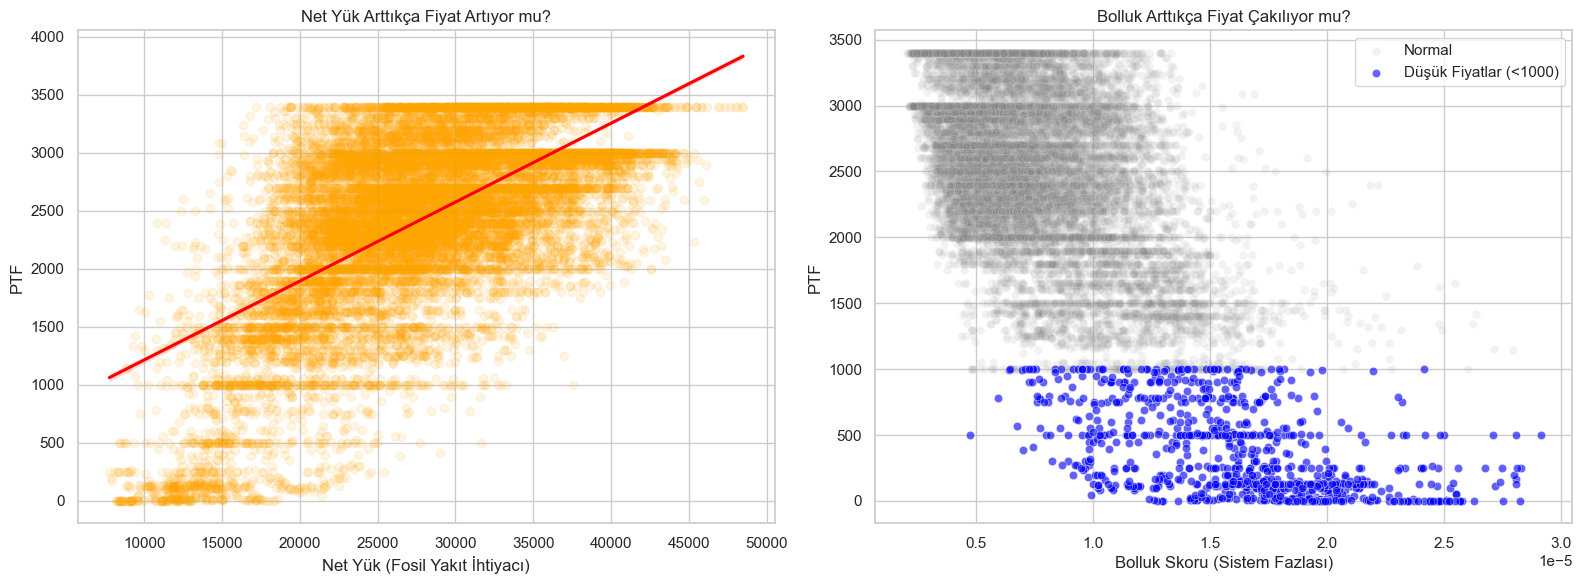

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ÖNCE SÜTUNLARI GARANTİLEYELİM
if 'Net_Yuk_Indeksi' not in veri.columns:
    # Net Yük = Toplam Yük - Yeşil Enerji Katkısı
    veri['Net_Yuk_Indeksi'] = veri['Yuk_Tahmin_Plani'] * (1 - veri['Yesil_Oran'])

if 'Bolluk_Skoru' not in veri.columns:
    # Bolluk = Yeşil Enerjinin Yüke Oranı (Arz Fazlası Riski)
    veri['Bolluk_Skoru'] = veri['Yesil_Oran'] / veri['Yuk_Tahmin_Plani']

# 2. KORELASYON HESABI
# Sadece ilgilendiğimiz sütunların korelasyon matrisini çıkaralım
corr_cols = ['PTF', 'Net_Yuk_Indeksi', 'Bolluk_Skoru', 'Maliyet_Baskisi']
corr_matrix = veri[corr_cols].corr()

print("KORELASYON ANALİZİ SONUÇLARI:")
print("-" * 40)
print(f"Net Yük İndeksi vs PTF : {corr_matrix.loc['Net_Yuk_Indeksi', 'PTF']:.4f}")
print(f"Bolluk Skoru vs PTF    : {corr_matrix.loc['Bolluk_Skoru', 'PTF']:.4f}")
print("-" * 40)

# 3. GÖRSEL KANIT (SCATTER PLOT)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Net Yük (Pozitif İlişki Bekliyoruz)
sns.regplot(x='Net_Yuk_Indeksi', y='PTF', data=veri, ax=axes[0], 
            scatter_kws={'alpha':0.1, 'color':'orange'}, line_kws={'color':'red'})
axes[0].set_title('Net Yük Arttıkça Fiyat Artıyor mu?')
axes[0].set_xlabel('Net Yük (Fosil Yakıt İhtiyacı)')

# Grafik 2: Bolluk Skoru (Negatif İlişki Bekliyoruz - Dip Fiyatlar)
# Özellikle PTF < 500 TL olan yerleri vurgulayalım
low_prices = veri[veri['PTF'] < 1000]
sns.scatterplot(x='Bolluk_Skoru', y='PTF', data=veri, alpha=0.1, color='gray', ax=axes[1], label='Normal')
sns.scatterplot(x='Bolluk_Skoru', y='PTF', data=low_prices, alpha=0.6, color='blue', ax=axes[1], label='Düşük Fiyatlar (<1000)')

axes[1].set_title('Bolluk Arttıkça Fiyat Çakılıyor mu?')
axes[1].set_xlabel('Bolluk Skoru (Sistem Fazlası)')
axes[1].legend()

plt.tight_layout()
plt.show()

 DİP FİYAT AVCISI MODEL (V3) EĞİTİLİYOR...

FİNAL MODEL V3 SONUÇLARI (Dip Fiyat Özellikleri Eklendi)
 MAE      : 221.32 TL (Hedef: <227 TL)
 R2 Skoru : 0.8225
 WMAPE    : %7.88
Dip Fiyatlar (<1000 TL) İçin Hata: 366.97 TL


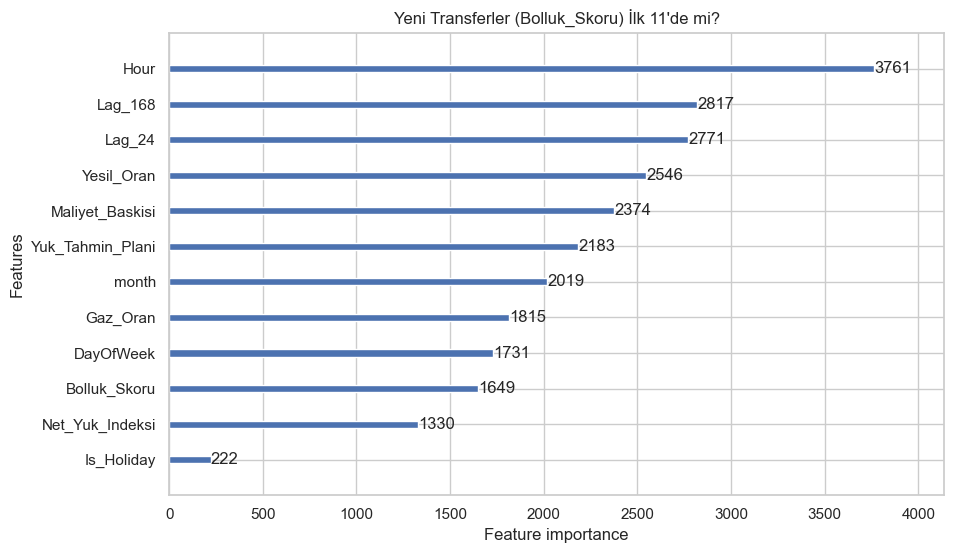

In [21]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(" DİP FİYAT AVCISI MODEL (V3) EĞİTİLİYOR...")

# 1. YENİ ÖZELLİKLERİ GARANTİLE
# (Eğer veri setinde yoksa tekrar oluşturalım)
if 'Net_Yuk_Indeksi' not in veri.columns:
    veri['Net_Yuk_Indeksi'] = veri['Yuk_Tahmin_Plani'] * (1 - veri['Yesil_Oran'])
if 'Bolluk_Skoru' not in veri.columns:
    veri['Bolluk_Skoru'] = veri['Yesil_Oran'] / veri['Yuk_Tahmin_Plani']

# 2. ŞAMPİYONLAR LİGİ KADROSU (SON HALİ)
features_v3 = [
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       
    'Lag_24', 'Lag_168',
    'Maliyet_Baskisi',  # Yüksek Fiyat Sorumlusu
    'Net_Yuk_Indeksi',  # Denge Sorumlusu (YENİ)
    'Bolluk_Skoru'      # Dip Fiyat Sorumlusu (YENİ)
]

# 3. VERİ AYRIMI
split_date = '2025-10-01'
model_df = veri.copy().dropna()

X_train_v3 = model_df[model_df.index < split_date][features_v3]
y_train_v3 = model_df[model_df.index < split_date]['PTF']
X_test_v3 = model_df[model_df.index >= split_date][features_v3]
y_test_v3 = model_df[model_df.index >= split_date]['PTF']

# 4. ŞAMPİYON PARAMETRELER (Manuel Sniper Ayarı)
# Bu ayarlar zaten rüştünü ispatlamıştı, değiştirmiyoruz.
params_champion = {
    'objective': 'regression', 'metric': 'mae',
    'n_estimators': 6000, 'learning_rate': 0.015,
    'num_leaves': 55, 'max_depth': 12, 'min_child_samples': 20,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': 42, 'n_jobs': -1, 'verbosity': -1
}

# 5. EĞİTİM
model_v3 = lgb.LGBMRegressor(**params_champion)

model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_test_v3, y_test_v3)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# 6. SONUÇLAR
preds_v3 = model_v3.predict(X_test_v3)

mae_v3 = mean_absolute_error(y_test_v3, preds_v3)
r2_v3 = r2_score(y_test_v3, preds_v3)
wmape_v3 = (sum(abs(y_test_v3 - preds_v3)) / sum(y_test_v3)) * 100

print("\n" + "="*50)
print(f"FİNAL MODEL V3 SONUÇLARI (Dip Fiyat Özellikleri Eklendi)")
print("="*50)
print(f" MAE      : {mae_v3:.2f} TL (Hedef: <227 TL)")
print(f" R2 Skoru : {r2_v3:.4f}")
print(f" WMAPE    : %{wmape_v3:.2f}")
print("="*50)

# --- KRİTİK KONTROL: DİP FİYATLARDA BAŞARIM ---
# Gerçek fiyatın 1000 TL altı olduğu saatlerdeki hataya bakalım
low_price_mask = y_test_v3 < 1000
if low_price_mask.sum() > 0:
    mae_low = mean_absolute_error(y_test_v3[low_price_mask], preds_v3[low_price_mask])
    print(f"Dip Fiyatlar (<1000 TL) İçin Hata: {mae_low:.2f} TL")
else:
    print("Test setinde 1000 TL altı fiyat yok.")

# Feature Importance
lgb.plot_importance(model_v3, max_num_features=15, title='Yeni Transferler (Bolluk_Skoru) İlk 11\'de mi?', figsize=(10, 6))
plt.show()

hiperparametre opt yapalım.

# Model

In [69]:
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

print("🚀 V3 MODELİ İÇİN HİPERPARAMETRE AVI BAŞLIYOR...")
print("(Hedef: 221 TL MAE'yi aşağı çekmek)")

# 1. ÖZELLİK SETİ (En Güçlü Kadro)
features_v3 = [
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       
    'Lag_24', 'Lag_168',
    'Maliyet_Baskisi',  
    'Net_Yuk_Indeksi',  
    'Bolluk_Skoru'      
]

# 2. VERİ SETİ HAZIRLIĞI
split_date = '2025-10-01'
model_df = veri.copy().dropna()

X_train_opt = model_df[model_df.index < split_date][features_v3]
y_train_opt = model_df[model_df.index < split_date]['PTF']
X_test_opt = model_df[model_df.index >= split_date][features_v3]
y_test_opt = model_df[model_df.index >= split_date]['PTF']

# 3. OPTUNA OBJECTIVE FONKSİYONU
def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': 7000, # Uzun soluklu olsun
        
        # 🧪 ARAMA UZAYI (Search Space)
        # Learning Rate'i biraz daha agresif arayalım
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.04),
        
        # Yeni özellikler karmaşık ilişkiler barındırıyor, yaprak sayısını artıralım
        'num_leaves': trial.suggest_int('num_leaves', 40, 100),
        
        # Derinlik: Bolluk skoru bazen çok spesifik kurallar gerektirebilir
        'max_depth': trial.suggest_int('max_depth', 8, 16),
        
        # Gürültü filtresi
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        
        # Regülarizasyon (Ezber önleyici)
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        
        # Örnekleme
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
    }

    model = lgb.LGBMRegressor(**param)
    
    model.fit(
        X_train_opt, y_train_opt,
        eval_set=[(X_test_opt, y_test_opt)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    preds = model.predict(X_test_opt)
    mae = mean_absolute_error(y_test_opt, preds)
    return mae

# 4. START VER
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25) # 25 deneme yapalım

print("\n" + "="*40)
print("🏆 OPTİMİZASYON SONUCU:")
print("="*40)
print(f"🥇 En İyi MAE: {study.best_value:.2f} TL")
print("🧩 En İyi Parametreler:", study.best_params)

# --- EN İYİ PARAMETRELERLE HEMEN MODELİ KURUP SONUCU GÖSTER ---
print("\n⚙️ En iyi parametrelerle Final Model Eğitiliyor...")
best_params = study.best_params
best_params.update({
    'objective': 'regression',
    'metric': 'mae',
    'n_estimators': 7000,
    'random_state': 42,
    'n_jobs': -1
})

final_opt_model = lgb.LGBMRegressor(**best_params)
final_opt_model.fit(
    X_train_opt, y_train_opt,
    eval_set=[(X_test_opt, y_test_opt)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

final_preds = final_opt_model.predict(X_test_opt)
final_r2 = r2_score(y_test_opt, final_preds)
final_mae = mean_absolute_error(y_test_opt, final_preds)
final_wmape = (np.sum(np.abs(y_test_opt - final_preds)) / np.sum(y_test_opt)) * 100

print("\n" + "="*50)
print(f"🏁 GRAND PRIX FİNALİ (Optimize Edilmiş V3)")
print("="*50)
print(f"🎯 R2 Skoru : {final_r2:.4f}")
print(f"📉 MAE      : {final_mae:.2f} TL (Önceki: 221.32)")
print(f"📊 WMAPE    : %{final_wmape:.2f}")
print("="*50)

[I 2025-12-25 22:17:28,769] A new study created in memory with name: no-name-58d8f2b7-5505-4e7e-8e8c-e9e57eb77d7d


🚀 V3 MODELİ İÇİN HİPERPARAMETRE AVI BAŞLIYOR...
(Hedef: 221 TL MAE'yi aşağı çekmek)


[I 2025-12-25 22:17:30,590] Trial 0 finished with value: 222.90775198048536 and parameters: {'learning_rate': 0.026053632533332045, 'num_leaves': 85, 'max_depth': 13, 'min_child_samples': 11, 'reg_alpha': 0.7147476985273947, 'reg_lambda': 0.538897809906575, 'subsample': 0.8630197215481892, 'colsample_bytree': 0.892574736822667}. Best is trial 0 with value: 222.90775198048536.
[I 2025-12-25 22:17:31,586] Trial 1 finished with value: 228.2693945762368 and parameters: {'learning_rate': 0.028343702607380217, 'num_leaves': 48, 'max_depth': 16, 'min_child_samples': 53, 'reg_alpha': 0.08604572120155185, 'reg_lambda': 0.0011041138170393427, 'subsample': 0.8363578602084848, 'colsample_bytree': 0.7194279965497672}. Best is trial 0 with value: 222.90775198048536.
[I 2025-12-25 22:17:32,482] Trial 2 finished with value: 232.76236692907227 and parameters: {'learning_rate': 0.028327302157437097, 'num_leaves': 50, 'max_depth': 15, 'min_child_samples': 24, 'reg_alpha': 0.07473933233212116, 'reg_lambda


🏆 OPTİMİZASYON SONUCU:
🥇 En İyi MAE: 219.45 TL
🧩 En İyi Parametreler: {'learning_rate': 0.00548041719799074, 'num_leaves': 62, 'max_depth': 16, 'min_child_samples': 46, 'reg_alpha': 0.324451961669342, 'reg_lambda': 0.6694193899450159, 'subsample': 0.9421979065969676, 'colsample_bytree': 0.9486386349499429}

⚙️ En iyi parametrelerle Final Model Eğitiliyor...

🏁 GRAND PRIX FİNALİ (Optimize Edilmiş V3)
🎯 R2 Skoru : 0.8230
📉 MAE      : 219.45 TL (Önceki: 221.32)
📊 WMAPE    : %7.81


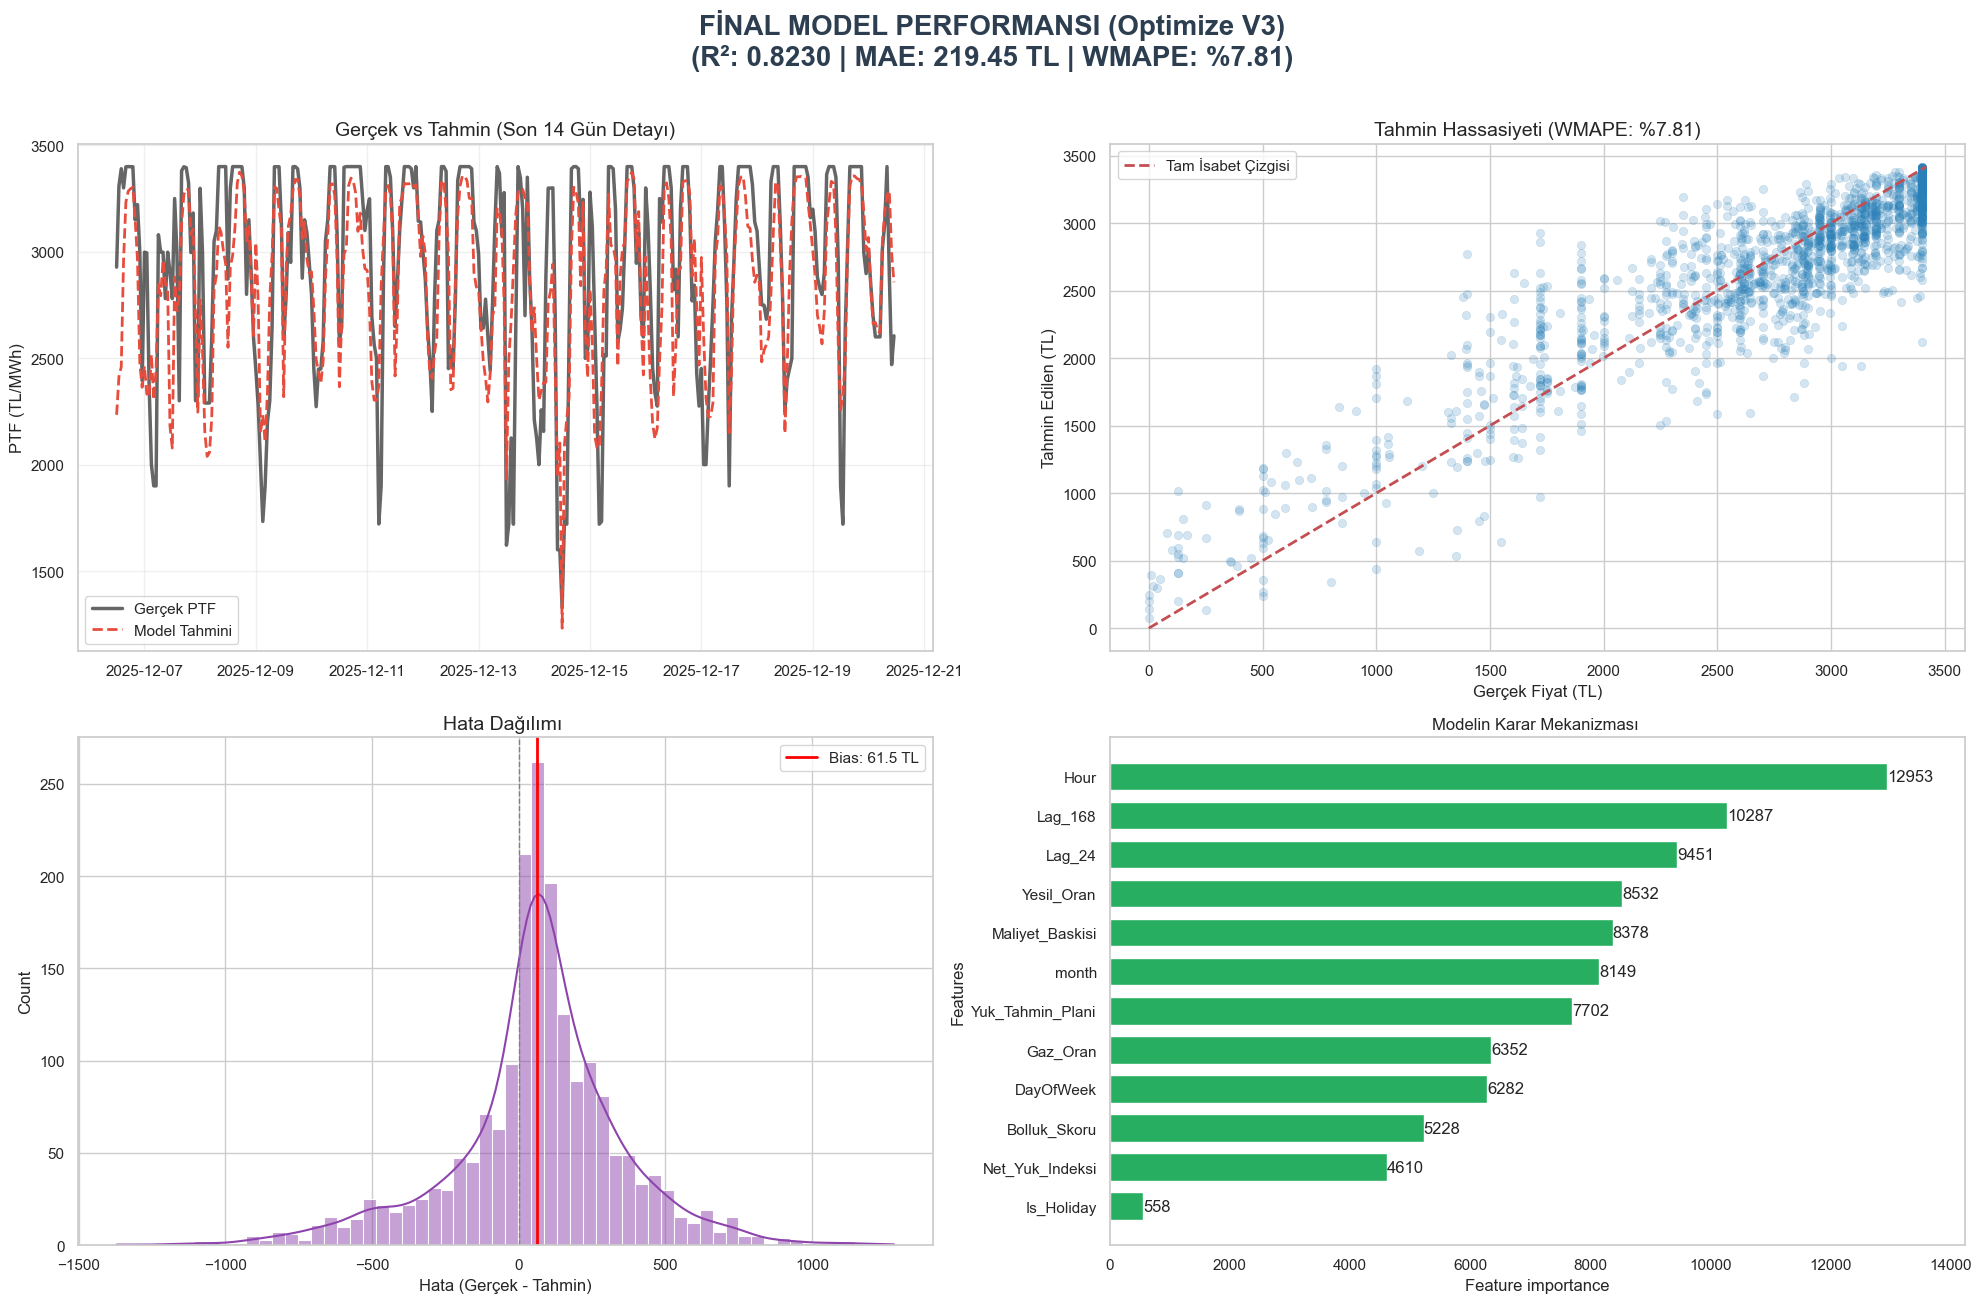

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Görsellik ayarları
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (20, 14)


# 1. TAHMİNLERİ AL (final_opt_model hafızada olmalı)
# Eğer hafızada yoksa, önceki adımdaki kodu çalıştırarak modeli oluşturman gerekir.
preds_final = final_opt_model.predict(X_test_opt)

# 2. METRİKLERİ HESAPLA
r2_val = r2_score(y_test_opt, preds_final)
mae_val = mean_absolute_error(y_test_opt, preds_final)
wmape_val = (np.sum(np.abs(y_test_opt - preds_final)) / np.sum(y_test_opt)) * 100
bias_val = np.mean(y_test_opt - preds_final)

# 3. GRAFİK PANELİ OLUŞTUR
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle(f"FİNAL MODEL PERFORMANSI (Optimize V3)\n(R²: {r2_val:.4f} | MAE: {mae_val:.2f} TL | WMAPE: %{wmape_val:.2f})", 
             fontsize=20, weight='bold', y=0.96, color='#2c3e50')

# --- GRAFİK 1 (SOL ÜST): Zaman Serisi (Zoom - Son 2 Hafta) ---
results_df = pd.DataFrame({'Gerçek': y_test_opt, 'Tahmin': preds_final}, index=X_test_opt.index)
# Son 336 saat (14 Gün)
zoom_data = results_df.tail(336) 

axes[0, 0].plot(zoom_data.index, zoom_data['Gerçek'], label='Gerçek PTF', color='black', linewidth=2.5, alpha=0.6)
axes[0, 0].plot(zoom_data.index, zoom_data['Tahmin'], label='Model Tahmini', color='#e74c3c', linestyle='--', linewidth=2)
axes[0, 0].set_title('Gerçek vs Tahmin (Son 14 Gün Detayı)', fontsize=14)
axes[0, 0].set_ylabel('PTF (TL/MWh)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# --- GRAFİK 2 (SAĞ ÜST): Scatter Plot (Hedef Tutturma) ---
sns.scatterplot(x=y_test_opt, y=preds_final, alpha=0.2, color='#2980b9', edgecolor=None, ax=axes[0, 1])
# İdeal Çizgi
limit = max(y_test_opt.max(), preds_final.max())
axes[0, 1].plot([0, limit], [0, limit], 'r--', linewidth=2, label='Tam İsabet Çizgisi')
axes[0, 1].set_title(f'Tahmin Hassasiyeti (WMAPE: %{wmape_val:.2f})', fontsize=14)
axes[0, 1].set_xlabel('Gerçek Fiyat (TL)')
axes[0, 1].set_ylabel('Tahmin Edilen (TL)')
axes[0, 1].legend()

# --- GRAFİK 3 (SOL ALT): Hata Dağılımı ve Bias ---
residuals = y_test_opt - preds_final
sns.histplot(residuals, bins=60, kde=True, color='#8e44ad', ax=axes[1, 0])
axes[1, 0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1, 0].axvline(bias_val, color='red', linestyle='-', linewidth=2, label=f'Bias: {bias_val:.1f} TL')
axes[1, 0].set_title('Hata Dağılımı ', fontsize=14)
axes[1, 0].set_xlabel('Hata (Gerçek - Tahmin)')
axes[1, 0].legend()

# --- GRAFİK 4 (SAĞ ALT): Feature Importance (Kritik Kontrol!) ---
lgb.plot_importance(final_opt_model, max_num_features=15, height=0.7, ax=axes[1, 1], 
                    title='Modelin Karar Mekanizması ', color='#27ae60')
axes[1, 1].grid(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [71]:
veri["PTF"].quantile([0.05,0.1, 0.25, 0.5, 0.75, 0.99])

0.05     989.00
0.10    1400.00
0.25    2078.27
0.50    2574.00
0.75    2989.99
0.99    3400.00
Name: PTF, dtype: float64

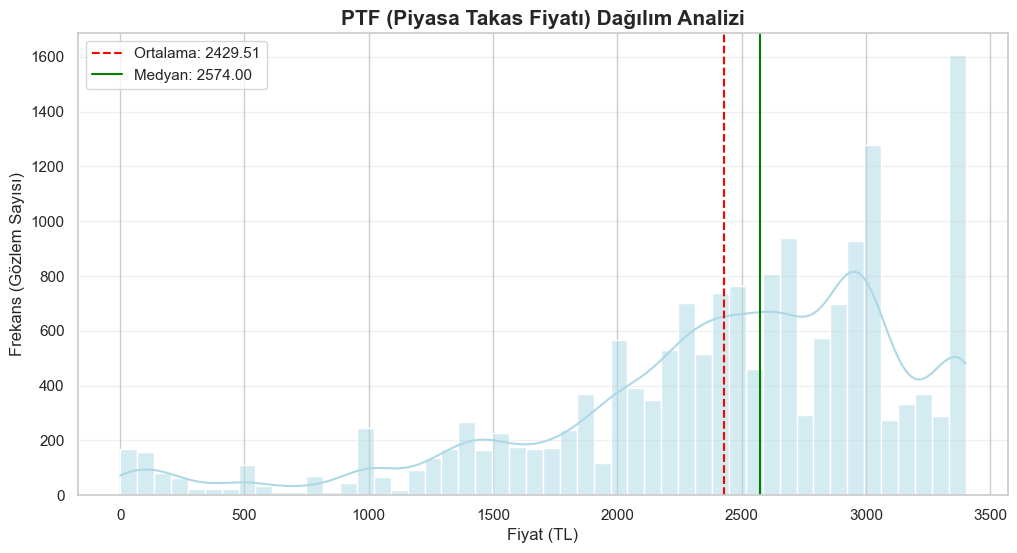

In [72]:
plt.figure(figsize=(12,6))
sns.histplot(x=veri["PTF"],
            kde=True,
            bins=50, 
            color='lightblue')
plt.axvline(veri['PTF'].mean(), color='red', linestyle='--', label=f"Ortalama: {veri['PTF'].mean():.2f}")
plt.axvline(veri['PTF'].median(), color='green', linestyle='-', label=f"Medyan: {veri['PTF'].median():.2f}")

plt.title('PTF (Piyasa Takas Fiyatı) Dağılım Analizi', fontsize=15, fontweight='bold')
plt.xlabel('Fiyat (TL)')
plt.ylabel('Frekans (Gözlem Sayısı)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()



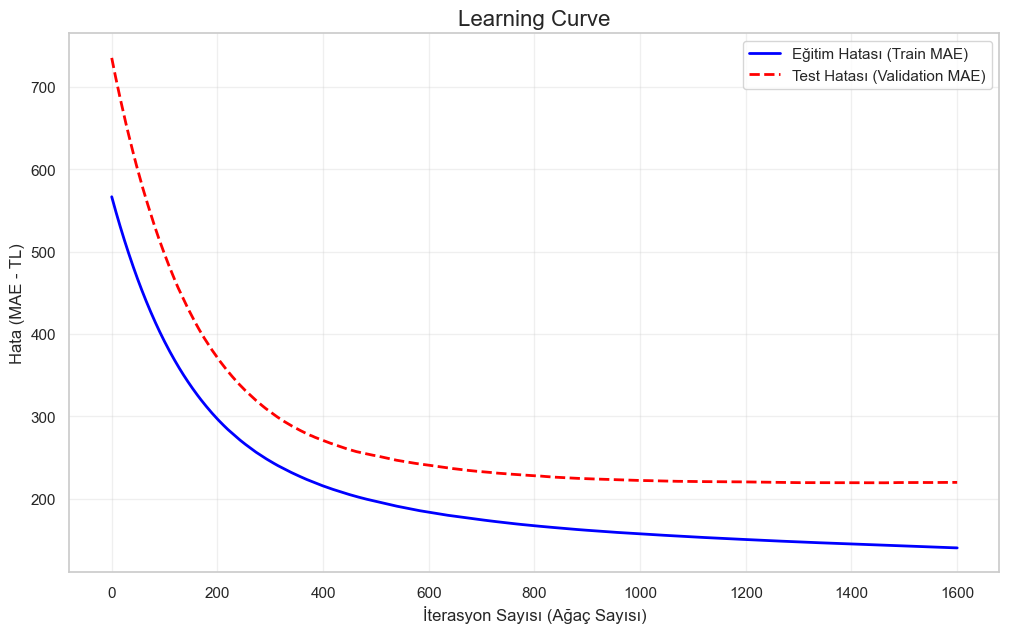

In [73]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# 1. MODELİ TEKRAR HAZIRLA (En iyi parametrelerle)
# eval_set içine HEM Train HEM Test setini veriyoruz ki ikisini de kaydetsin.
final_opt_model.fit(
    X_train_opt, y_train_opt,
    eval_set=[(X_train_opt, y_train_opt), (X_test_opt, y_test_opt)],
    eval_names=['Egitim', 'Test'],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# 2. KAYITLARI ÇEK
results = final_opt_model.evals_result_
epochs = len(results['Egitim']['l1']) # l1 = MAE
x_axis = range(0, epochs)

# 3. GRAFİĞİ ÇİZ
plt.figure(figsize=(12, 7))

# Eğitim Hatası
plt.plot(x_axis, results['Egitim']['l1'], label='Eğitim Hatası (Train MAE)', color='blue', linewidth=2)
# Test Hatası
plt.plot(x_axis, results['Test']['l1'], label='Test Hatası (Validation MAE)', color='red', linewidth=2, linestyle='--')

plt.title('Learning Curve', fontsize=16)
plt.xlabel('İterasyon Sayısı (Ağaç Sayısı)', fontsize=12)
plt.ylabel('Hata (MAE - TL)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Son puanları grafiğe yazalım
final_train_err = results['Egitim']['l1'][-1]
final_test_err = results['Test']['l1'][-1]
gap = final_test_err - final_train_err


plt.show()

In [74]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16861 entries, 2024-01-18 23:00:00 to 2025-12-20 11:00:00
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   PTF               16861 non-null  float64 
 1   month             16861 non-null  category
 2   day               16861 non-null  category
 3   season            16861 non-null  category
 4   Rolling_Mean_168  16861 non-null  float64 
 5   Is_Holiday        16861 non-null  category
 6   Is_Weekend        16861 non-null  category
 7   Lag_24            16861 non-null  float64 
 8   Lag_168           16861 non-null  float64 
 9   Lag_48            16861 non-null  float64 
 10  Lag_72            16861 non-null  float64 
 11  Lag_96            16861 non-null  float64 
 12  Hour              16861 non-null  int32   
 13  DayOfWeek         16861 non-null  int32   
 14  Yuk_Tahmin_Plani  16861 non-null  int64   
 15  yesil_enerji      16861 non-null  f

# Detaylı Model Analizi


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Stil ayarları (Grafiklerin güzel görünmesi için)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [45]:
final_opt_model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 0.8801001677019173,
 'importance_type': 'split',
 'learning_rate': 0.013223748579679524,
 'max_depth': 8,
 'min_child_samples': 28,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 7000,
 'n_jobs': -1,
 'num_leaves': 56,
 'objective': 'regression',
 'random_state': 42,
 'reg_alpha': 0.2999628095476164,
 'reg_lambda': 0.23736323910946083,
 'subsample': 0.8610619723837896,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'metric': 'mae'}

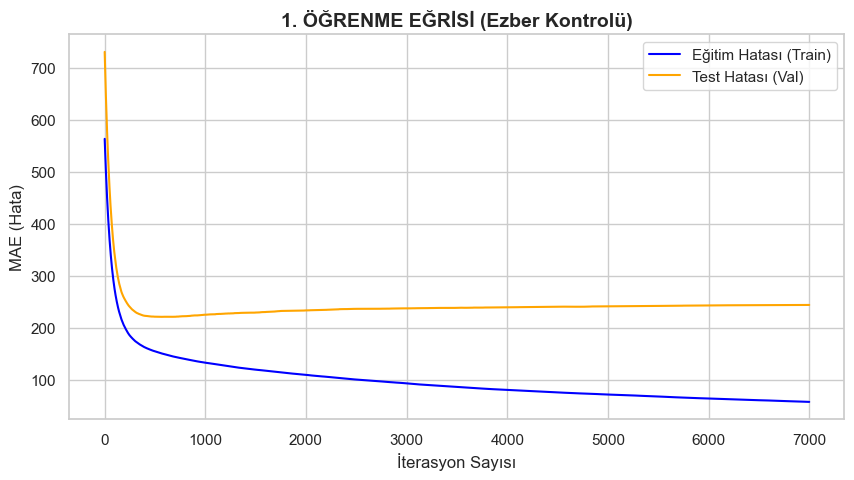

--------------------------------------------------


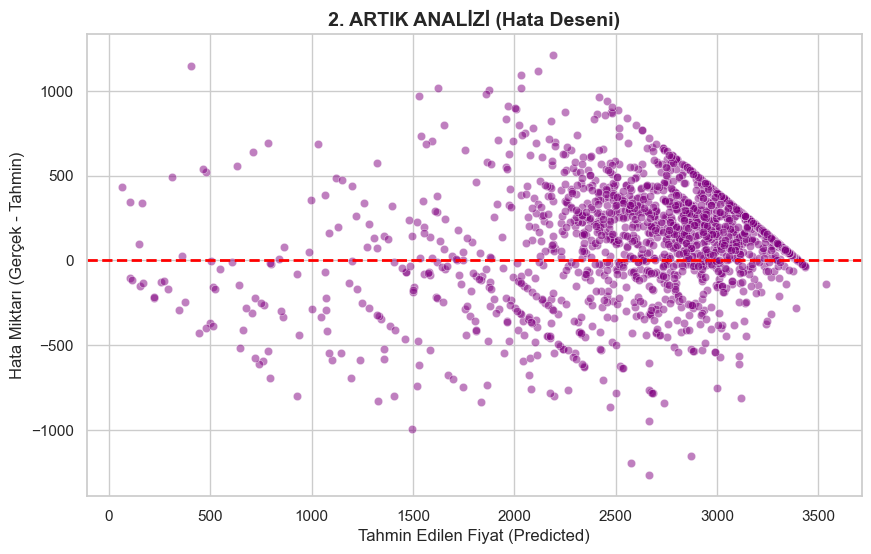

--------------------------------------------------


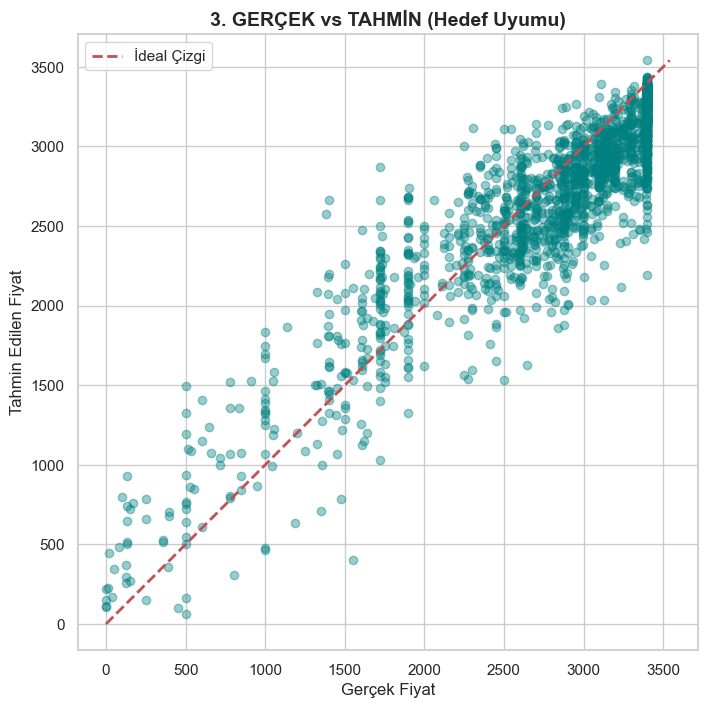

--------------------------------------------------


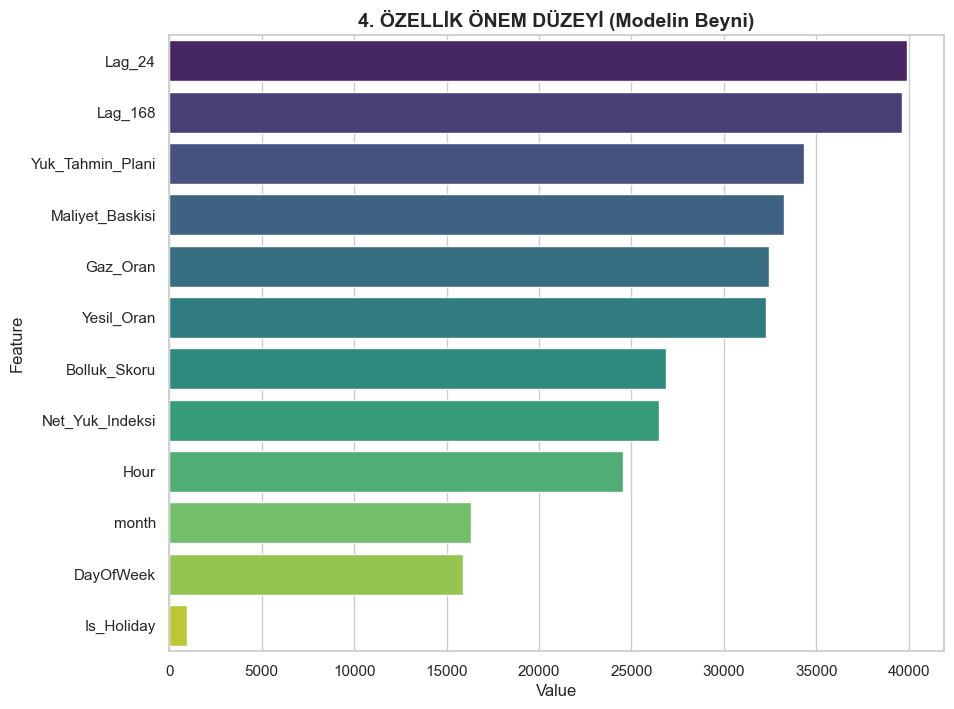

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import lightgbm as lgb

# Grafik stilleri
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


# -------------------------------------------------------------------------
# ADIM 1: VERİLERİ HAZIRLA VE MODELİ (LOGLARI TUTACAK ŞEKİLDE) TAZELE
# -------------------------------------------------------------------------
# Not: Learning Curve görebilmek için eval_set içinde hem Train hem Test olmalı.
final_opt_model.fit(
    X_train_opt, y_train_opt,
    eval_set=[(X_train_opt, y_train_opt), (X_test_opt, y_test_opt)],
    eval_names=['Eğitim', 'Doğrulama'],
    eval_metric='mae',
    callbacks=[lgb.log_evaluation(0)] # Çıktı kirliliği olmasın diye logları gizledim
)

# Tahminleri al
y_pred_final = final_opt_model.predict(X_test_opt)
residuals = y_test_opt - y_pred_final

# -------------------------------------------------------------------------
# ADIM 2: GRAFİKLERİ OLUŞTUR
# -------------------------------------------------------------------------

# --- GRAFİK 1: LEARNING CURVE (Bias vs Variance) ---
def plot_learning_curve():
    results = final_opt_model.evals_result_
    epochs = len(results['Eğitim']['l1'])
    x_axis = range(0, epochs)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_axis, results['Eğitim']['l1'], label='Eğitim Hatası (Train)', color='blue')
    plt.plot(x_axis, results['Doğrulama']['l1'], label='Test Hatası (Val)', color='orange')
    plt.title('1. ÖĞRENME EĞRİSİ (Ezber Kontrolü)', fontsize=14, fontweight='bold')
    plt.xlabel('İterasyon Sayısı')
    plt.ylabel('MAE (Hata)')
    plt.legend()
    plt.show()

# --- GRAFİK 2: RESIDUAL PLOT (Hata Deseni) ---
def plot_residuals():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.5, color='purple')
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.title('2. ARTIK ANALİZİ (Hata Deseni)', fontsize=14, fontweight='bold')
    plt.xlabel('Tahmin Edilen Fiyat (Predicted)')
    plt.ylabel('Hata Miktarı (Gerçek - Tahmin)')
    plt.show()

# --- GRAFİK 3: ACTUAL VS PREDICTED (Doğruluk) ---
def plot_actual_vs_pred():
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test_opt, y_pred_final, alpha=0.4, color='teal')
    
    # Mükemmel tahmin çizgisi (y=x)
    limit = max(y_test_opt.max(), y_pred_final.max())
    plt.plot([0, limit], [0, limit], 'r--', linewidth=2, label='İdeal Çizgi')
    
    plt.title('3. GERÇEK vs TAHMİN (Hedef Uyumu)', fontsize=14, fontweight='bold')
    plt.xlabel('Gerçek Fiyat')
    plt.ylabel('Tahmin Edilen Fiyat')
    plt.axis('equal')
    plt.legend()
    plt.show()

# --- GRAFİK 4: FEATURE IMPORTANCE ---
def plot_importance():
    importance = pd.DataFrame({
        'Feature': X_train_opt.columns,
        'Value': final_opt_model.feature_importances_
    }).sort_values(by='Value', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Value', y='Feature', data=importance, palette='viridis')
    plt.title('4. ÖZELLİK ÖNEM DÜZEYİ (Modelin Beyni)', fontsize=14, fontweight='bold')
    plt.show()

# Fonksiyonları sırayla çağır
plot_learning_curve()
print("-" * 50)
plot_residuals()
print("-" * 50)
plot_actual_vs_pred()
print("-" * 50)
plot_importance()

In [53]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score

print("V4 MODELİ EĞİTİLİYOR: Log-Transformation Stratejisi...")

# 1. VERİ HAZIRLIĞI (V3 ile aynı özellikler)
y_train_v4 = np.log1p(y_train_opt)
y_test_v4 = np.log1p(y_test_opt)

# 2. MODEL KURULUMU (V3 Parametrelerini Aynen Kullanıyoruz)
v4_model = lgb.LGBMRegressor(**best_params)

# 3. EĞİTİM
v4_model.fit(
    X_train_opt, y_train_v4,
    eval_set=[(X_test_opt, y_test_v4)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# 4. TAHMİN VE GERİ DÖNÜŞÜM (Inverse Transform)
preds_log = v4_model.predict(X_test_opt)
final_preds_v4 = np.expm1(preds_log) 

# 5. PERFORMANS ÖLÇÜMÜ
v4_mae = mean_absolute_error(y_test_opt, final_preds_v4)
v4_r2 = r2_score(y_test_opt, final_preds_v4)
v4_wmape = (np.sum(np.abs(y_test_opt - final_preds_v4)) / np.sum(y_test_opt)) * 100

print("\n" + "="*50)
print(f"V4 SONUÇLARI (Log-Transformed)")
print("="*50)
print(f"MAE      : {v4_mae:.2f} TL (V3: {final_mae:.2f})")
print(f"R2 Skoru : {v4_r2:.4f}")
print(f"WMAPE    : %{v4_wmape:.2f}")
print("="*50)

# Farkı kontrol et
fark = final_mae - v4_mae
if fark > 0: 
    print(f"Başarılı! Log dönüşümü MAE'yi {fark:.2f} TL aşağı çekti.")
else:
    print(f"Dikkat: MAE {abs(fark):.2f} TL arttı. Dağılım hala dirençli olabilir.")

V4 MODELİ EĞİTİLİYOR: Log-Transformation Stratejisi...

V4 SONUÇLARI (Log-Transformed)
MAE      : 241.18 TL (V3: 220.92)
R2 Skoru : 0.7949
WMAPE    : %8.58
Dikkat: MAE 20.26 TL arttı. Dağılım hala dirençli olabilir.


Fikir: Bir model "Normal/Yüksek Fiyatlar" için, diğer model "Düşük/Sıfır Fiyatlar" için mi eğitilmeli?
O zaman v3 modelimizde hatanın en büyük olduğu gözlemlerin ptf'sine bakalım. 

                     Gerçek_PTF   Tahmin_PTF      Hata_TL  Mutlak_Hata_TL
2025-11-17 15:00:00     1399.99  2729.487510 -1329.497510     1329.497510
2025-10-25 10:00:00     3129.99  1858.424426  1271.565574     1271.565574
2025-11-22 07:00:00     3400.00  2164.992507  1235.007493     1235.007493
2025-12-13 15:00:00     1719.98  2928.389385 -1208.409385     1208.409385
2025-12-06 00:00:00     1719.99  2873.421500 -1153.431500     1153.431500
...                         ...          ...          ...             ...
2025-11-16 14:00:00     1327.39  1587.182299  -259.792299      259.792299
2025-11-04 13:00:00     2235.01  2494.511284  -259.501284      259.501284
2025-11-13 10:00:00     3399.45  3140.298993   259.151007      259.151007
2025-10-28 09:00:00     3400.00  3141.110340   258.889660      258.889660
2025-11-09 04:00:00     2873.78  2614.950564   258.829436      258.829436

[600 rows x 4 columns]

HATA SEGMENTASYONU
----------------------------------------
Hatalı 600 örneğin Gerçek F

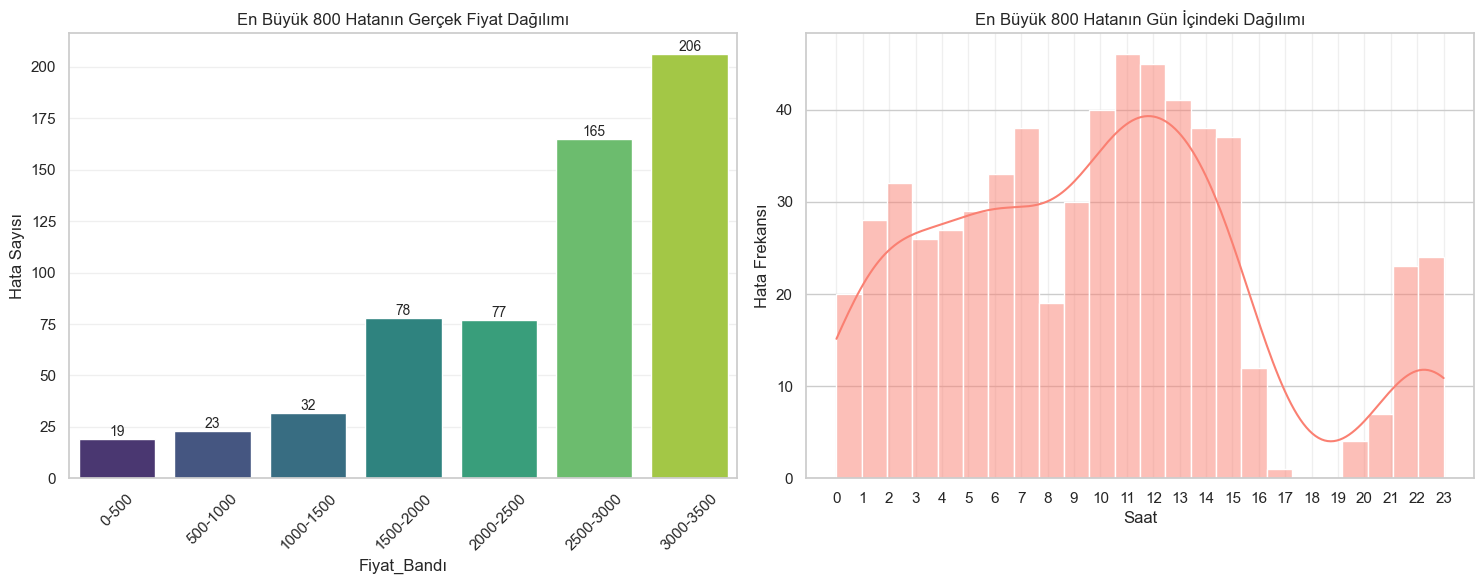

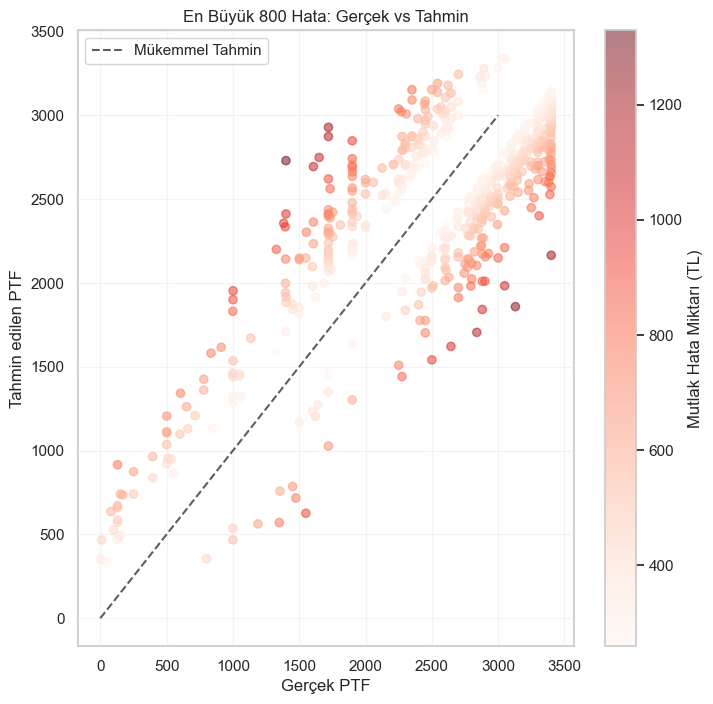

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

count=800

# 1. 500 TL'lik Bantları Oluşturma
bins = np.arange(0, error_analysis_df['Gerçek_PTF'].max() + 500, 500)
labels = [f"{int(i)}-{int(i+500)}" for i in bins[:-1]]
top_errors['Fiyat_Bandı'] = pd.cut(top_errors['Gerçek_PTF'], bins=bins, labels=labels)

plt.figure(figsize=(15, 6))

# GRAFİK 1: Hangi Fiyat Bantlarında Hata Yapıyoruz?
plt.subplot(1, 2, 1)
sns.countplot(data=top_errors, x='Fiyat_Bandı', palette='viridis', order=labels)
plt.title(f'En Büyük {count} Hatanın Gerçek Fiyat Dağılımı', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Hata Sayısı')
plt.grid(axis='y', alpha=0.3)

# Sayıları sütunların üzerine yazalım
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, xytext=(0, 5), textcoords='offset points')

# GRAFİK 2: Saatlik Hata Dağılımı (Isı Haritası gibi)
plt.subplot(1, 2, 2)
sns.histplot(top_errors['Hour'], bins=24, kde=True, color='salmon')
plt.title(f'En Büyük {count} Hatanın Gün İçindeki Dağılımı', fontsize=12)
plt.xlabel('Saat')
plt.ylabel('Hata Frekansı')
plt.xticks(range(0, 24))
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Scatter Plot: Gerçek vs Tahmin (Hata Şiddeti)
plt.figure(figsize=(8, 8))
plt.scatter(top_errors['Gerçek_PTF'], top_errors['Tahmin_PTF'], alpha=0.5, c=top_errors['Mutlak_Hata_TL'], cmap='Reds')
plt.plot([0, 3000], [0, 3000], '--k', alpha=0.7, label='Mükemmel Tahmin')
plt.title(f'En Büyük {count} Hata: Gerçek vs Tahmin')
plt.xlabel('Gerçek PTF')
plt.ylabel('Tahmin edilen PTF')
plt.colorbar(label='Mutlak Hata Miktarı (TL)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [96]:
veri["PTF"].quantile([0.01,0.05,0.1, 0.25, 0.5, 0.75, 0.9,0.95,0.99])

0.01      59.774
0.05     989.000
0.10    1400.000
0.25    2078.270
0.50    2574.000
0.75    2989.990
0.90    3300.060
0.95    3400.000
0.99    3400.000
Name: PTF, dtype: float64

In [77]:
import optuna
import lightgbm as lgb
# Buraya MSE ve RMSE için gerekli olan mean_squared_error'u ekledik
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')


# 1. ÖZELLİK SETİ (Aynı kadro)
features_v3 = [
    'Hour', 'DayOfWeek', 'month', 'Is_Holiday',
    'Yuk_Tahmin_Plani',
    'Yesil_Oran', 
    'Gaz_Oran',       
    'Lag_24', 'Lag_168',
    'Maliyet_Baskisi',  
    'Net_Yuk_Indeksi',  
    'Bolluk_Skoru'      
]

# 2. VERİ SETİ HAZIRLIĞI
split_date = '2025-10-01'
model_df = veri.copy().dropna()

X_train_opt = model_df[model_df.index < split_date][features_v3]
y_train_opt = model_df[model_df.index < split_date]['PTF']
X_test_opt = model_df[model_df.index >= split_date][features_v3]
y_test_opt = model_df[model_df.index >= split_date]['PTF']

# 3. OPTUNA OBJECTIVE FONKSİYONU
def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': 7000, 
        
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.04),
        'num_leaves': trial.suggest_int('num_leaves', 40, 100),
        'max_depth': trial.suggest_int('max_depth', 8, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
    }

    model = lgb.LGBMRegressor(**param)
    
    model.fit(
        X_train_opt, y_train_opt,
        eval_set=[(X_test_opt, y_test_opt)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    preds = model.predict(X_test_opt)
    mae = mean_absolute_error(y_test_opt, preds)
    return mae

# 4. START VER
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25)

print("\n" + "="*40)
print("OPTİMİZASYON SONUCU:")
print("="*40)
print(f"En İyi MAE: {study.best_value:.2f} TL")

# --- EN İYİ PARAMETRELERLE HEMEN MODELİ KURUP SONUCU GÖSTER ---
best_params = study.best_params
best_params.update({
    'objective': 'regression',
    'metric': 'mae',
    'n_estimators': 7000,
    'random_state': 42,
    'n_jobs': -1
})

final_opt_model = lgb.LGBMRegressor(**best_params)
final_opt_model.fit(
    X_train_opt, y_train_opt,
    eval_set=[(X_test_opt, y_test_opt)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=150, verbose=False)]
)

# --- ÇIKTI HESAPLAMALARI ---
final_preds = final_opt_model.predict(X_test_opt)
final_r2 = r2_score(y_test_opt, final_preds)
final_mae = mean_absolute_error(y_test_opt, final_preds)
final_mse = mean_squared_error(y_test_opt, final_preds)
final_rmse = np.sqrt(final_mse) # MSE'nin karekökü RMSE verir
final_wmape = (np.sum(np.abs(y_test_opt - final_preds)) / np.sum(y_test_opt)) * 100

print("\n" + "="*50)
print(f"v3 hata metrikleri")
print("="*50)
print(f"R2 Skoru  : {final_r2:.4f}")
print(f"MAE       : {final_mae:.2f} TL")
print(f"MSE       : {final_mse:.2f}")
print(f"RMSE      : {final_rmse:.2f} TL")
print(f"WMAPE     : %{final_wmape:.2f}")
print("="*50)


[I 2025-12-25 22:23:36,897] A new study created in memory with name: no-name-7496b054-7955-4a74-bc9b-4bf72a78bec9


[I 2025-12-25 22:23:37,978] Trial 0 finished with value: 226.67256408823098 and parameters: {'learning_rate': 0.03752941704720552, 'num_leaves': 54, 'max_depth': 8, 'min_child_samples': 25, 'reg_alpha': 0.5815687942816216, 'reg_lambda': 0.3732782333047595, 'subsample': 0.9458612000728897, 'colsample_bytree': 0.8655795379205895}. Best is trial 0 with value: 226.67256408823098.
[I 2025-12-25 22:23:38,933] Trial 1 finished with value: 229.94001207458777 and parameters: {'learning_rate': 0.0374017719813717, 'num_leaves': 74, 'max_depth': 12, 'min_child_samples': 50, 'reg_alpha': 0.6942122377678316, 'reg_lambda': 0.05447060370406265, 'subsample': 0.7476002747738367, 'colsample_bytree': 0.7094543454208297}. Best is trial 0 with value: 226.67256408823098.
[I 2025-12-25 22:23:42,603] Trial 2 finished with value: 224.26325929822778 and parameters: {'learning_rate': 0.0070264362867081525, 'num_leaves': 63, 'max_depth': 8, 'min_child_samples': 38, 'reg_alpha': 0.5133963124659214, 'reg_lambda': 0.


OPTİMİZASYON SONUCU:
En İyi MAE: 220.03 TL

v3 hata metrikleri
R2 Skoru  : 0.8233
MAE       : 220.03 TL
MSE       : 91516.89
RMSE      : 302.52 TL
WMAPE     : %7.83


In [85]:
import joblib
joblib.dump(final_opt_model, 'final_v3_model_mae220.pkl')

['final_v3_model_mae220.pkl']

In [88]:
veri.columns

Index(['PTF', 'month', 'day', 'season', 'Rolling_Mean_168', 'Is_Holiday',
       'Is_Weekend', 'Lag_24', 'Lag_168', 'Lag_48', 'Lag_72', 'Lag_96', 'Hour',
       'DayOfWeek', 'Yuk_Tahmin_Plani', 'yesil_enerji', 'fosil_enerji',
       'Yesil_Oran', 'Fosil_Oran', 'Gaz_Oran', 'USD_TRY', 'Dogalgaz_Fiyati',
       'Maliyet_Baskisi', 'Gun_Tipi', 'Net_Yuk_Indeksi', 'Bolluk_Skoru'],
      dtype='object')

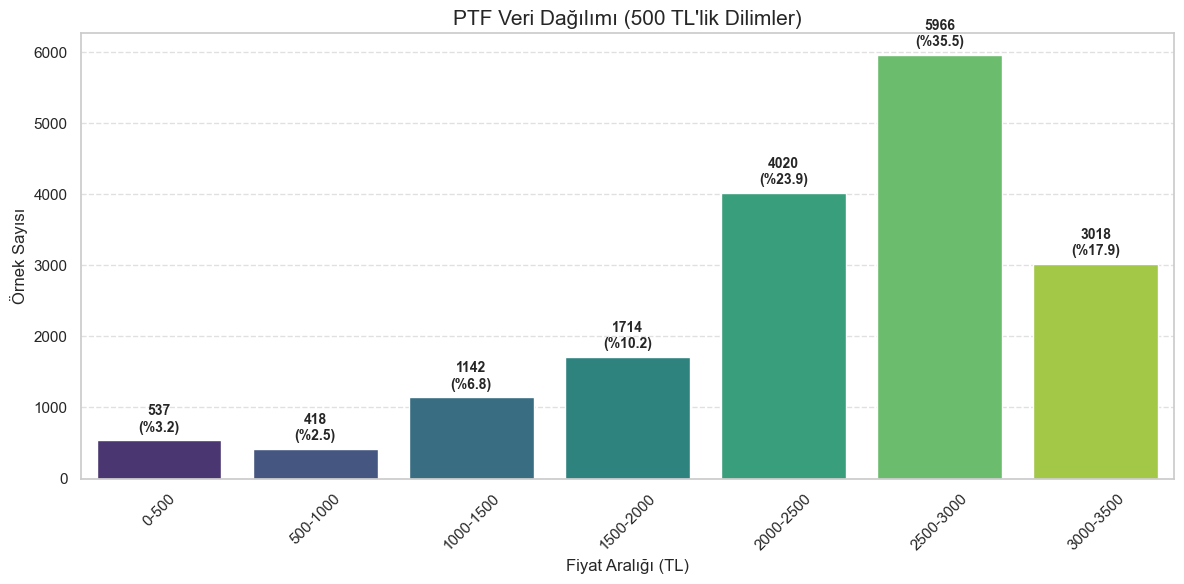

  Fiyat_Araligi  Veri_Sayisi      Yuzde
0         0-500          537   3.193577
1      500-1000          418   2.485876
2     1000-1500         1142   6.791555
3     1500-2000         1714  10.193280
4     2000-2500         4020  23.907226
5     2500-3000         5966  35.480226
6     3000-3500         3018  17.948260


In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 500 TL'lik dilimleri (bins) oluşturalım
# Verinin minimum ve maksimum değerine göre dinamik aralık belirleyelim
bins = list(range(0, int(model_df['PTF'].max()) + 500, 500))
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# 2. Veriyi dilimlere ayıralım
dist_df = pd.cut(model_df['PTF'], bins=bins, labels=labels).value_counts().sort_index().reset_index()
dist_df.columns = ['Fiyat_Araligi', 'Veri_Sayisi']
dist_df['Yuzde'] = (dist_df['Veri_Sayisi'] / dist_df['Veri_Sayisi'].sum()) * 100

# 3. Görselleştirme
plt.figure(figsize=(12, 6))
barplot = sns.barplot(x='Fiyat_Araligi', y='Veri_Sayisi', data=dist_df, palette='viridis')

# Çubukların üzerine sayıları ve yüzdeleri yazalım
for i, p in enumerate(barplot.patches):
    barplot.annotate(f'{int(p.get_height())}\n(%{dist_df["Yuzde"].iloc[i]:.1f})', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 15), 
                     textcoords = 'offset points',
                     fontsize=10, fontweight='bold')

plt.title('PTF Veri Dağılımı (500 TL\'lik Dilimler)', fontsize=15)
plt.xlabel('Fiyat Aralığı (TL)')
plt.ylabel('Örnek Sayısı')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Özet tabloyu yazdır
print(dist_df)